In [ ]:
# Import library untuk manipulasi dan analisis data
import numpy as np
import pandas as pd

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing dan pemodelan
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Import library untuk evaluasi model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Import library untuk balancing data
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

# Import library untuk menyimpan model
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport!")

Semua library berhasil diimport!
Semua library berhasil diimport!


In [ ]:
# Load dataset dari Files Colab
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')

print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")

Dataset berhasil dimuat!
Jumlah baris: 15000, Jumlah kolom: 30
Dataset berhasil dimuat!
Jumlah baris: 15000, Jumlah kolom: 30


### Analisis Data Eksplorasi (EDA)

In [ ]:
print("=" * 60)
print("5 BARIS PERTAMA DATASET")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
print(df.describe())

5 BARIS PERTAMA DATASET
   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_requested  delivery_delay_days  pay

PERSENTASE MISSING VALUE
coupon_code           40.886667
age                    8.000000
total_spent            7.000000
gender                 4.920000
satisfaction_score     4.680000
dtype: float64


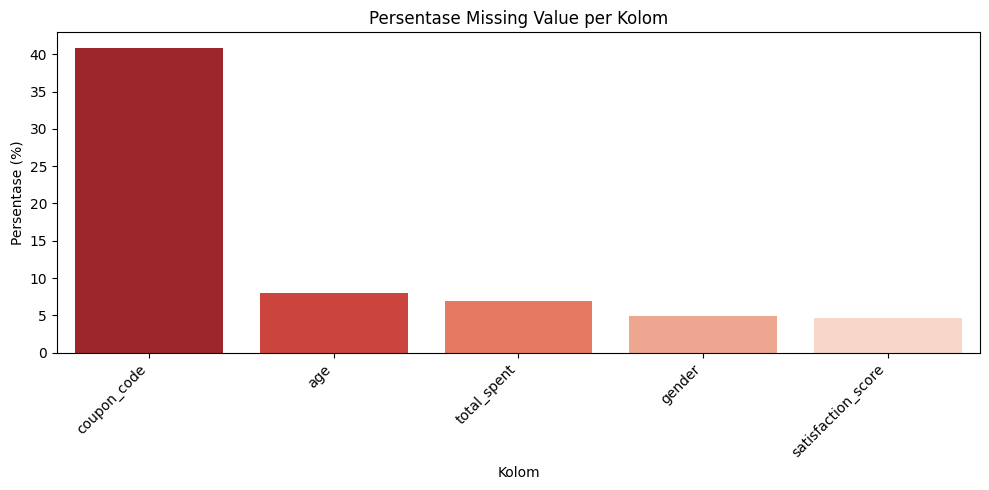

PERSENTASE MISSING VALUE
coupon_code           40.886667
age                    8.000000
total_spent            7.000000
gender                 4.920000
satisfaction_score     4.680000
dtype: float64


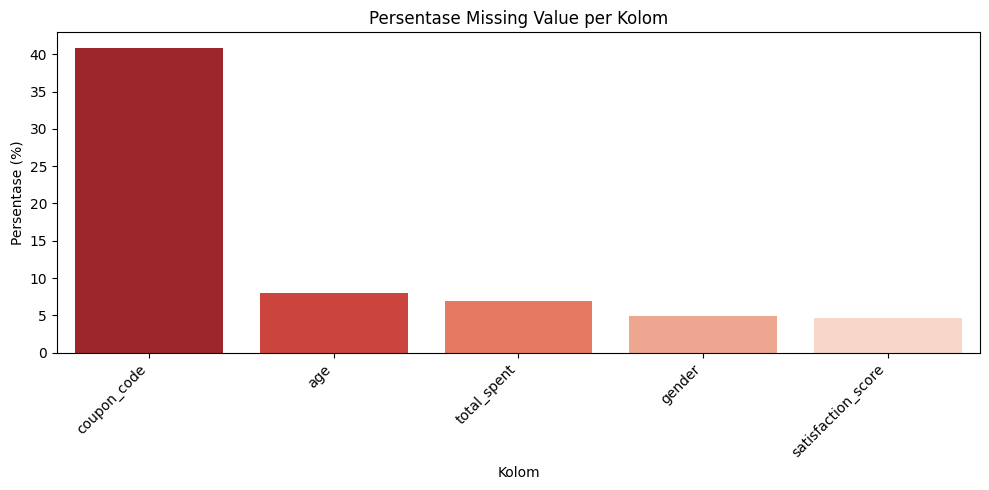

In [ ]:
print("=" * 60)
print("PERSENTASE MISSING VALUE")
print("=" * 60)
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.index, y=missing.values, palette='Reds_r')
plt.title('Persentase Missing Value per Kolom')
plt.xlabel('Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

DISTRIBUSI VARIABEL TARGET (CHURN)
       Jumlah  Persentase (%)
churn                        
0       12702           84.68
1        2298           15.32


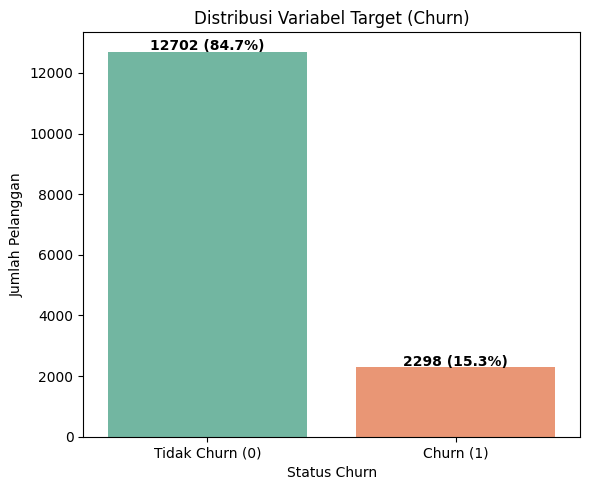

DISTRIBUSI VARIABEL TARGET (CHURN)
       Jumlah  Persentase (%)
churn                        
0       12702           84.68
1        2298           15.32


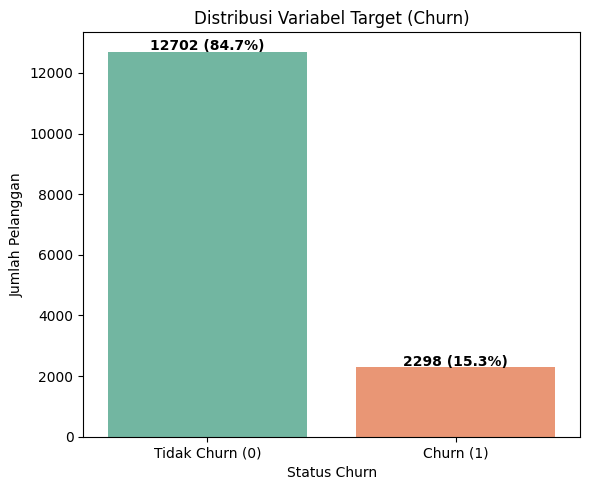

In [ ]:
print("=" * 60)
print("DISTRIBUSI VARIABEL TARGET (CHURN)")
print("=" * 60)
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Jumlah': churn_counts, 'Persentase (%)': churn_pct}))

plt.figure(figsize=(6, 5))
sns.barplot(x=churn_counts.index.map({0: 'Tidak Churn (0)', 1: 'Churn (1)'}),
            y=churn_counts.values, palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Status Churn')
plt.ylabel('Jumlah Pelanggan')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, f'{v} ({churn_pct.values[i]:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

HEATMAP KORELASI FITUR NUMERIK


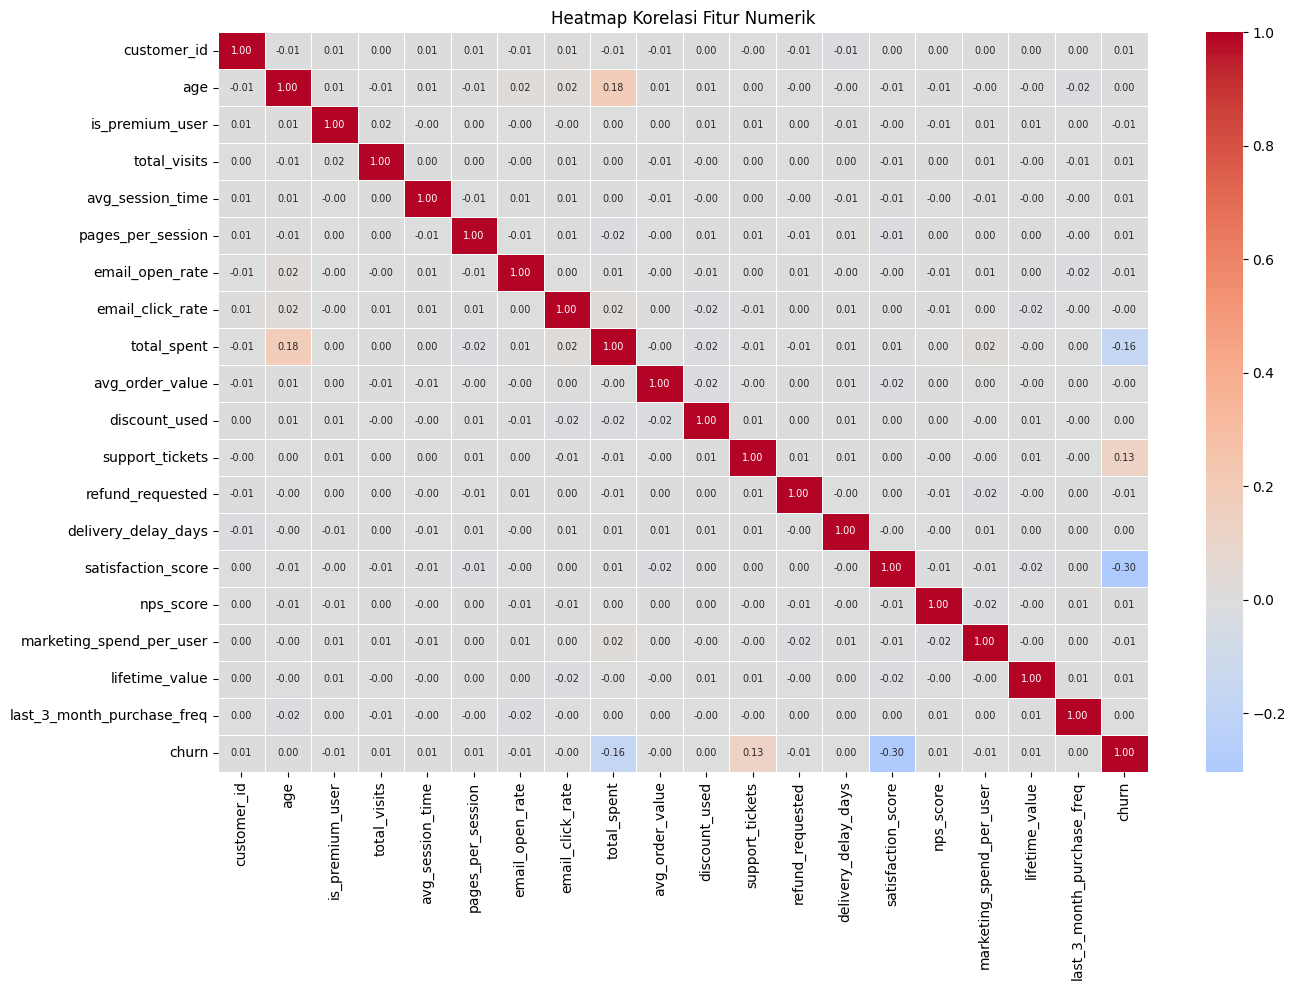


Korelasi fitur terhadap Churn (diurutkan):
support_tickets               0.127910
total_visits                  0.013212
customer_id                   0.012208
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588
Name: churn, dtype: float64
HEATMAP KORELASI FITUR NUMERIK


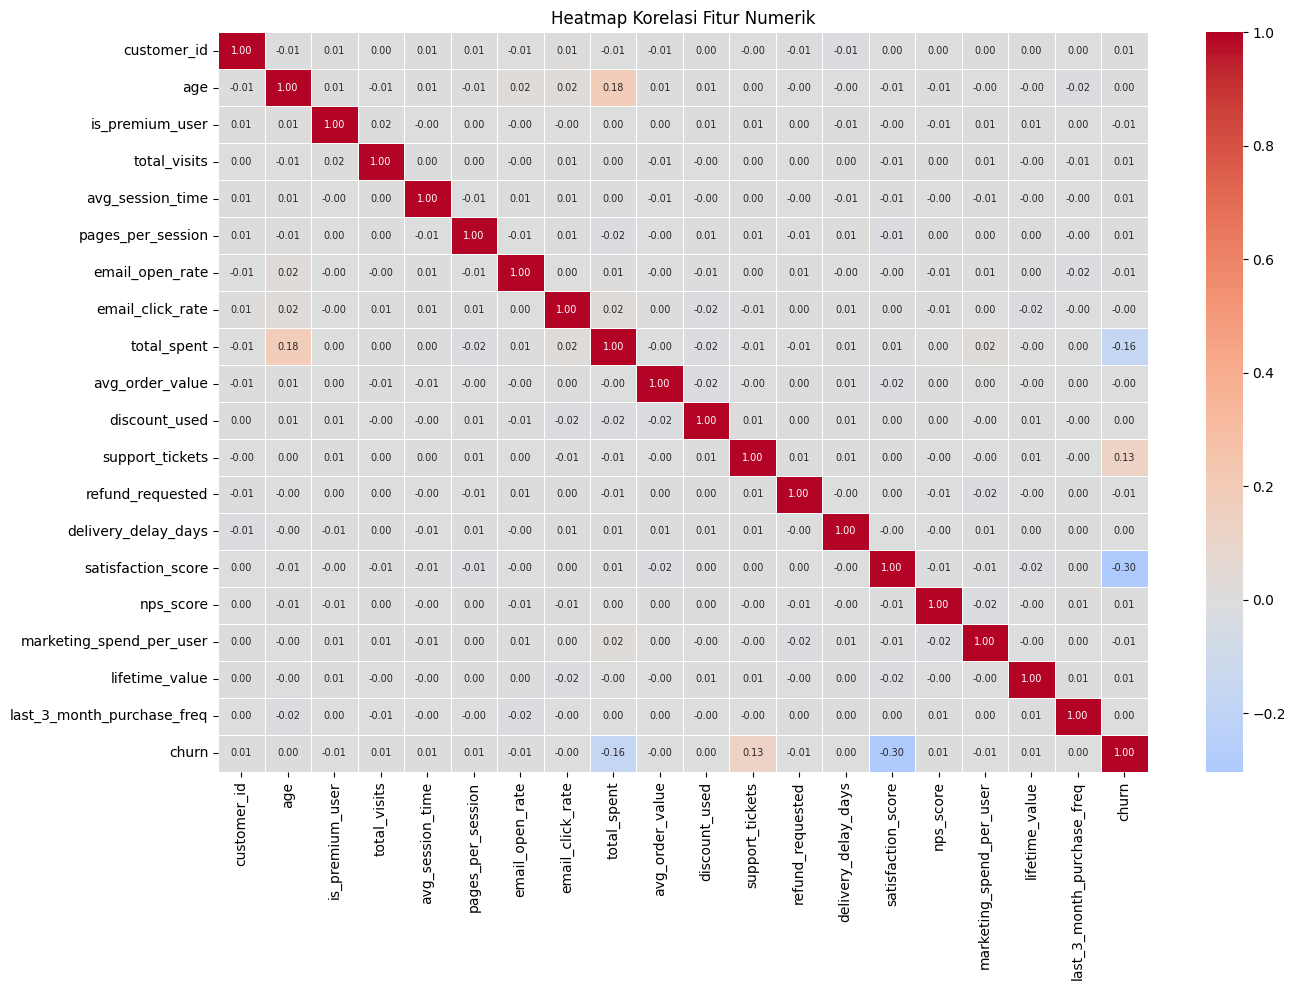


Korelasi fitur terhadap Churn (diurutkan):
support_tickets               0.127910
total_visits                  0.013212
customer_id                   0.012208
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588
Name: churn, dtype: float64


In [ ]:
print("=" * 60)
print("HEATMAP KORELASI FITUR NUMERIK")
print("=" * 60)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

print("\nKorelasi fitur terhadap Churn (diurutkan):")
print(corr_matrix['churn'].drop('churn').sort_values(ascending=False))

DETEKSI OUTLIER (METODE IQR)
churn                  2298
refund_requested       2215
satisfaction_score      753
delivery_delay_days     184
age                      89
support_tickets          79
total_spent              78
lifetime_value           56
avg_order_value          54
avg_session_time         45
total_visits             39
pages_per_session        33
dtype: int64


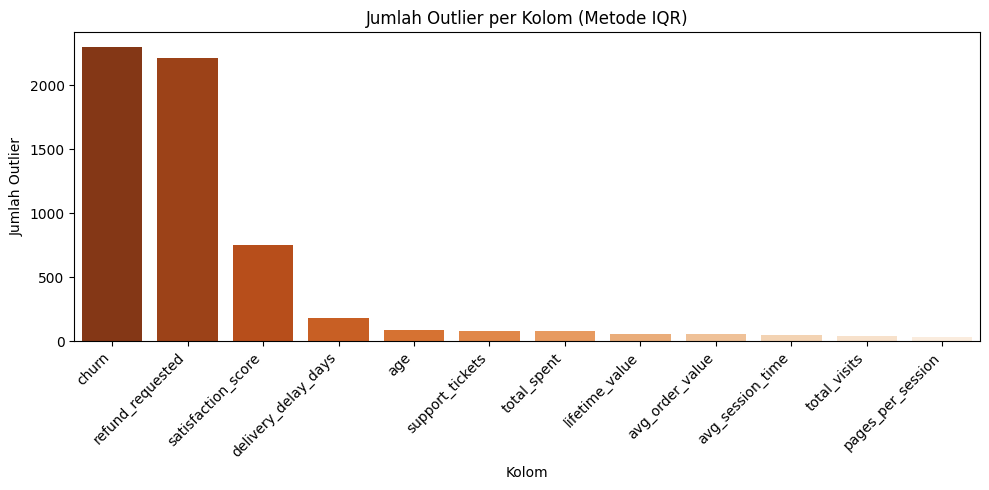

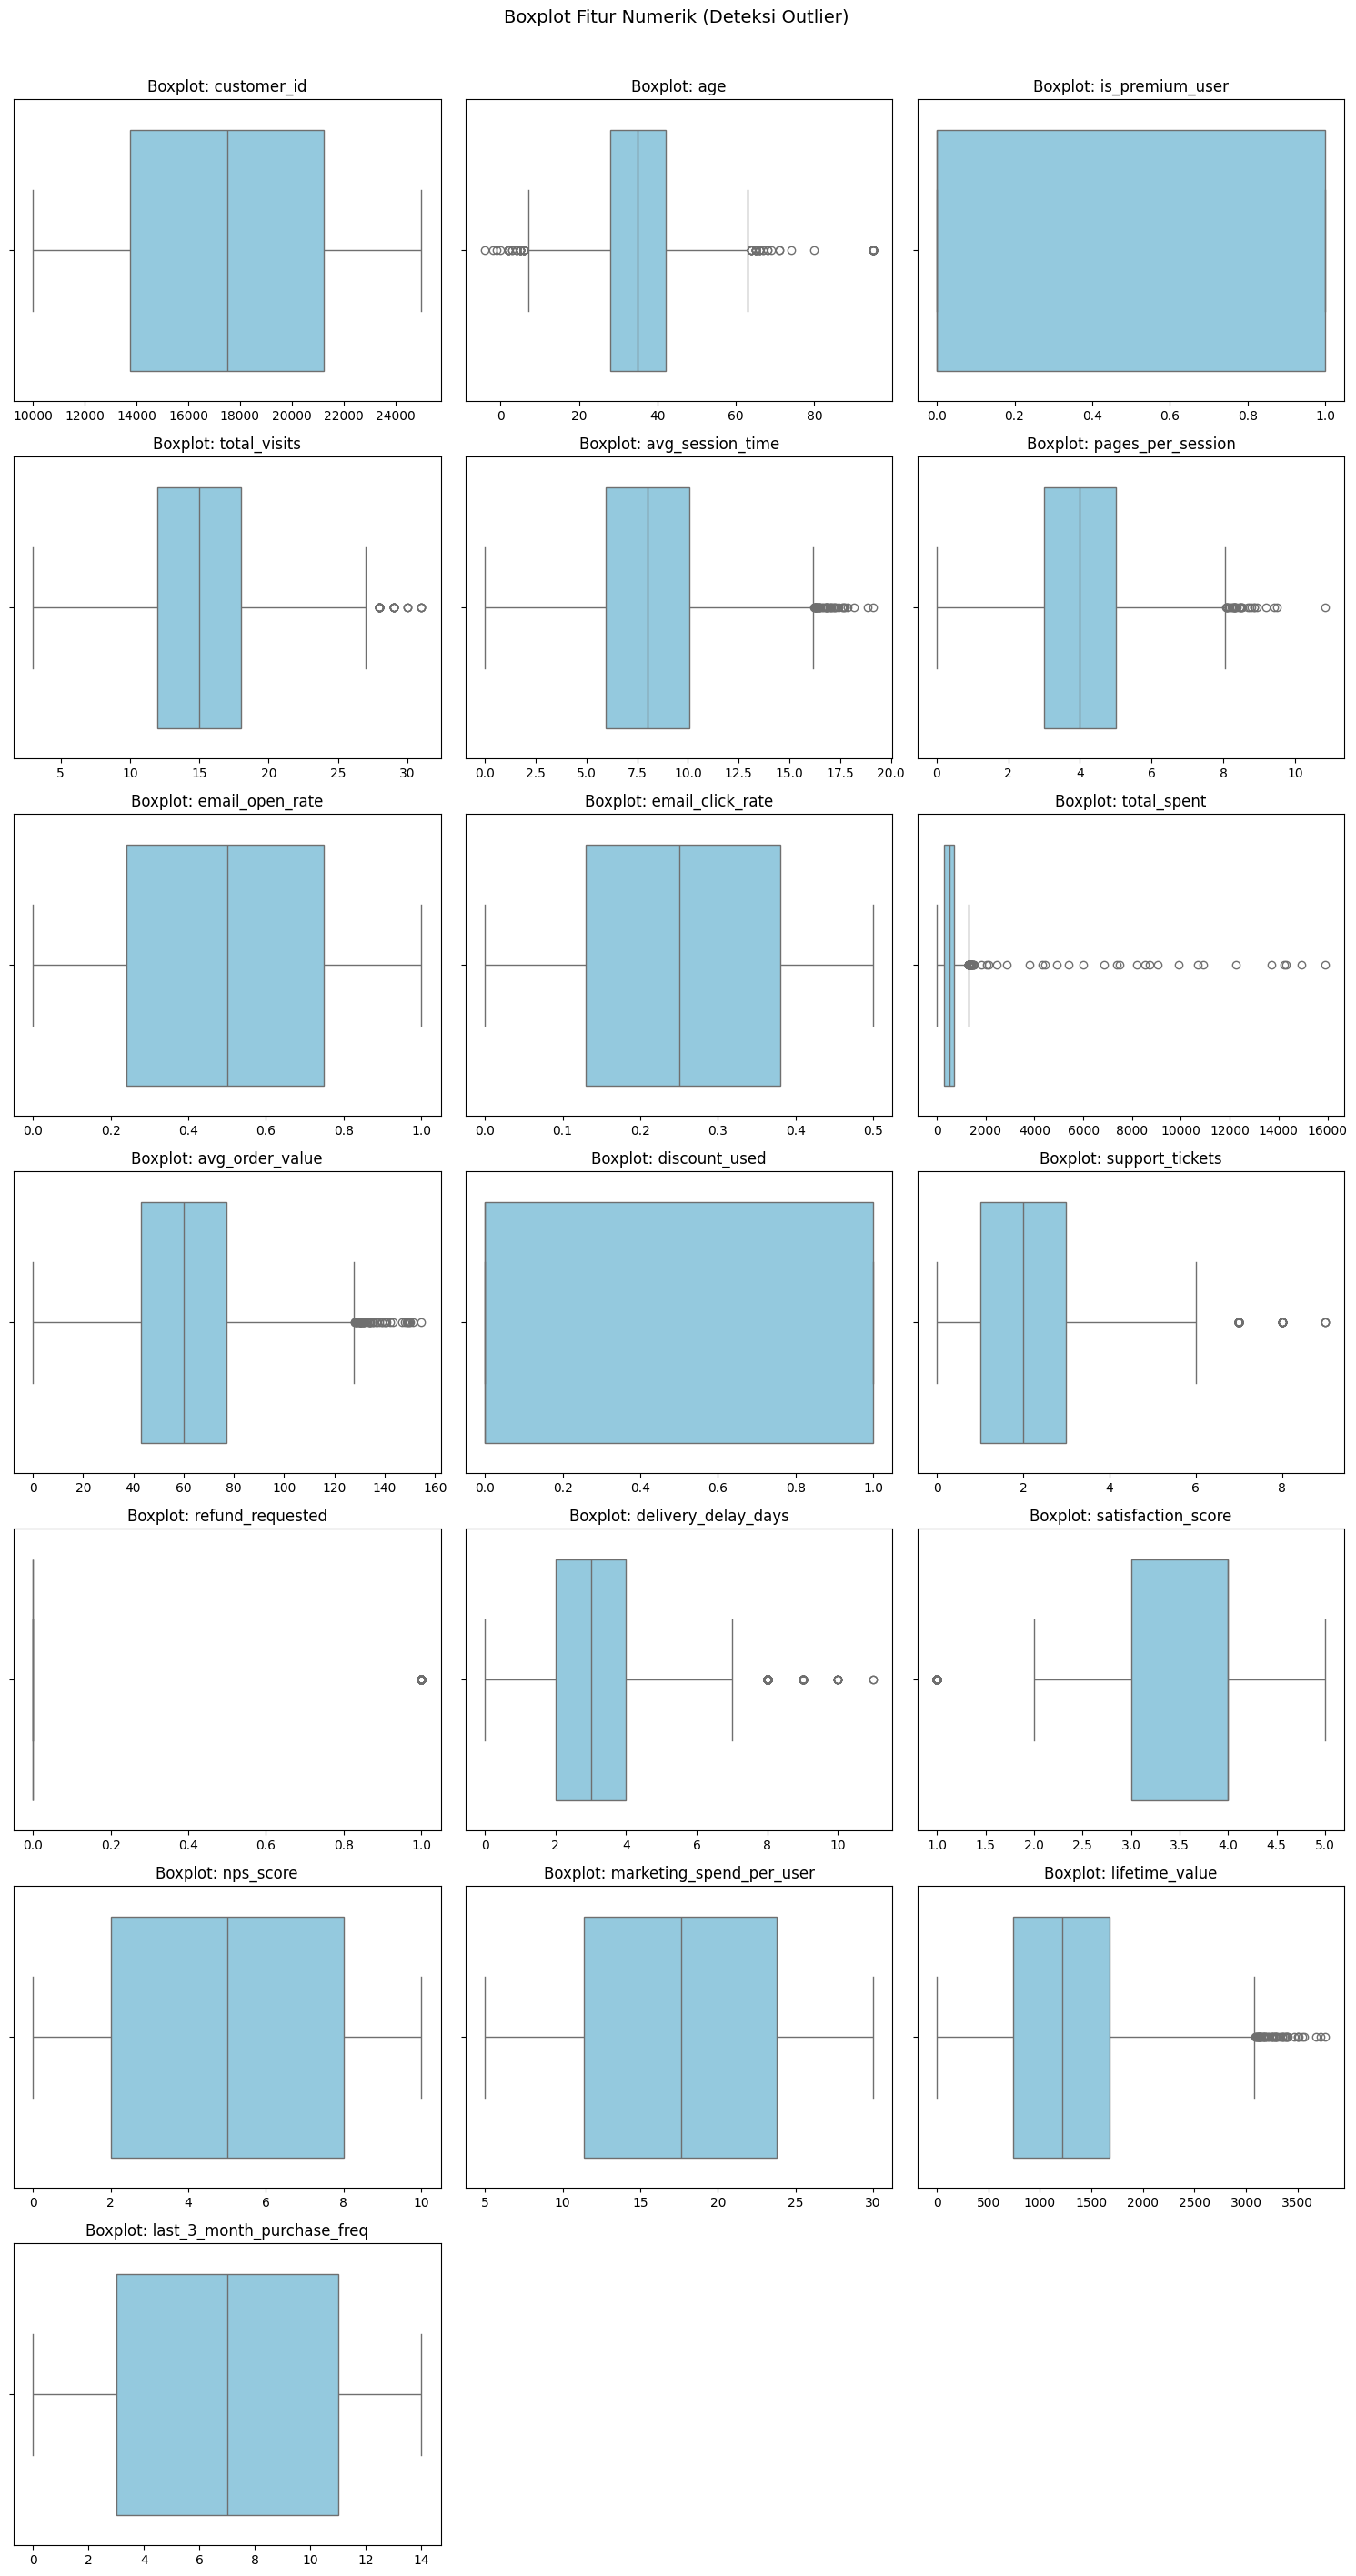

DETEKSI OUTLIER (METODE IQR)
churn                  2298
refund_requested       2215
satisfaction_score      753
delivery_delay_days     184
age                      89
support_tickets          79
total_spent              78
lifetime_value           56
avg_order_value          54
avg_session_time         45
total_visits             39
pages_per_session        33
dtype: int64


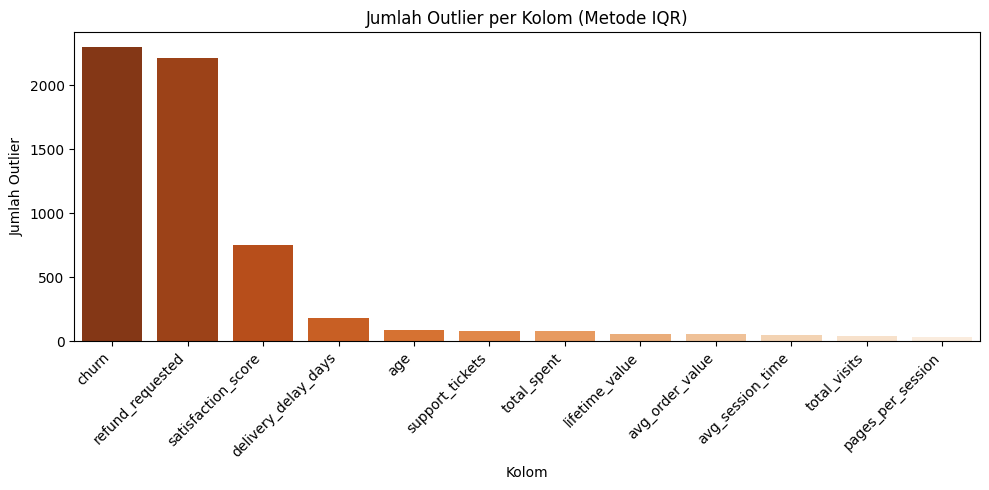

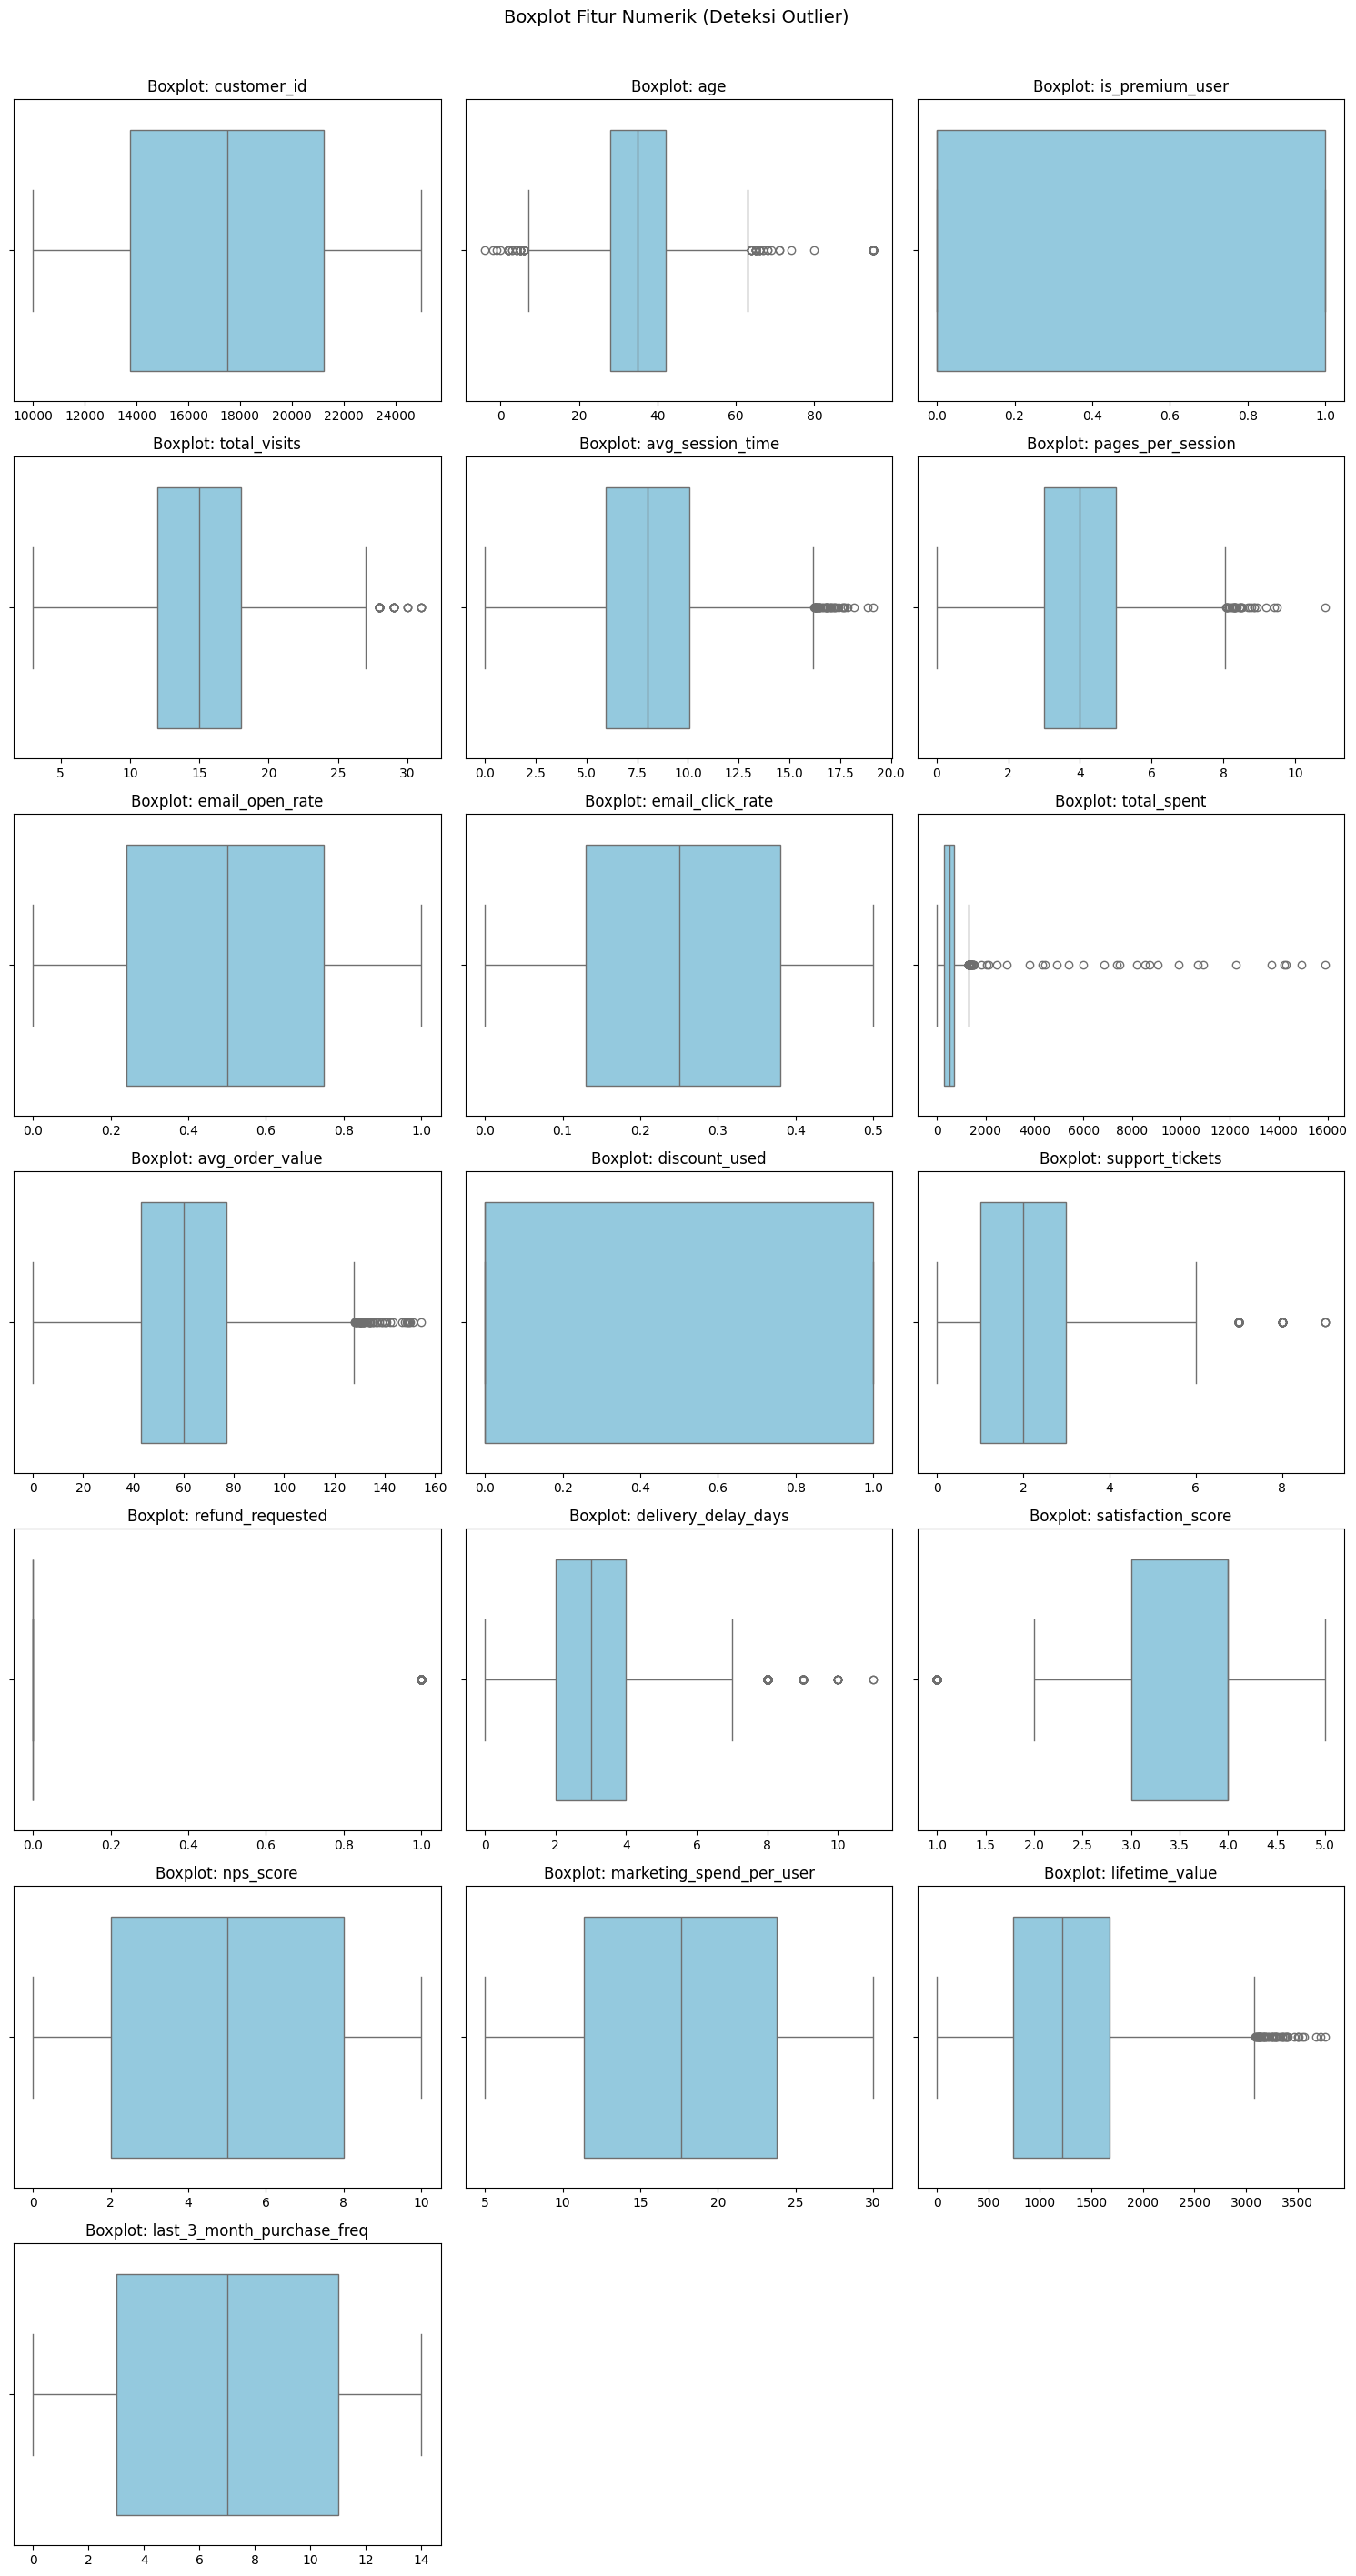

In [ ]:
print("=" * 60)
print("DETEKSI OUTLIER (METODE IQR)")
print("=" * 60)

outlier_info = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = n_outlier

outlier_df = pd.Series(outlier_info).sort_values(ascending=False)
outlier_df = outlier_df[outlier_df > 0]
print(outlier_df)

plt.figure(figsize=(10, 5))
sns.barplot(x=outlier_df.index, y=outlier_df.values, palette='Oranges_r')
plt.title('Jumlah Outlier per Kolom (Metode IQR)')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

num_cols_no_target = [col for col in num_cols if col != 'churn']
n = len(num_cols_no_target)
ncols = 3
nrows = (n + ncols - 1) // ncols

plt.figure(figsize=(15, nrows * 4))
for i, col in enumerate(num_cols_no_target):
    plt.subplot(nrows, ncols, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel('')
plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Upaya Pemodelan Awal (Baseline)

In [ ]:
# Drop kolom kategorikal dan id untuk direct modeling
cat_cols = df.select_dtypes(include='object').columns.tolist()
X = df.drop(columns=['churn', 'customer_id'] + cat_cols)
y = df['churn']

# Isi missing value dengan median
X = X.fillna(X.median())

print("Kolom yang digunakan:", X.columns.tolist())
print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Missing value:", X.isnull().sum().sum())

Kolom yang digunakan: ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']
Shape X: (15000, 18)
Shape y: (15000,)
Missing value: 0
Kolom yang digunakan: ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']
Shape X: (15000, 18)
Shape y: (15000,)
Missing value: 0


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi 3 model
lr = LogisticRegression(random_state=42)
rf = RandomForestClassifier(random_state=42)
voting = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=42)),
    ('svm', SVC(random_state=42)),
    ('knn', KNeighborsClassifier())
], voting='hard')

# Training ketiga model tanpa preprocessing dan tanpa tuning
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
voting.fit(X_train, y_train)

print("Ketiga model berhasil dilatih!")

Ketiga model berhasil dilatih!



Model: Logistic Regression
Accuracy  : 0.8463
Precision : 0.4388
Recall    : 0.1374
F1-Score  : 0.2093

Confusion Matrix:


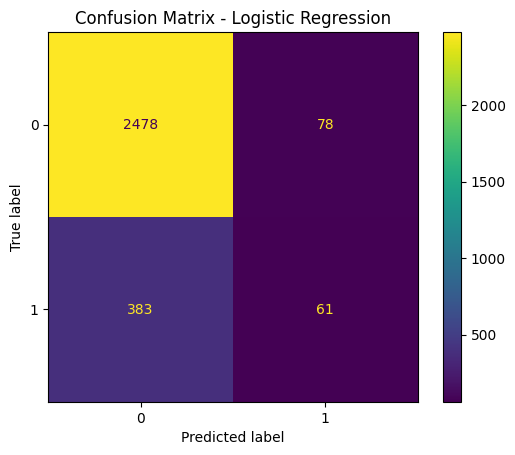


Model: Random Forest
Accuracy  : 0.8403
Precision : 0.4507
Recall    : 0.3604
F1-Score  : 0.4005

Confusion Matrix:


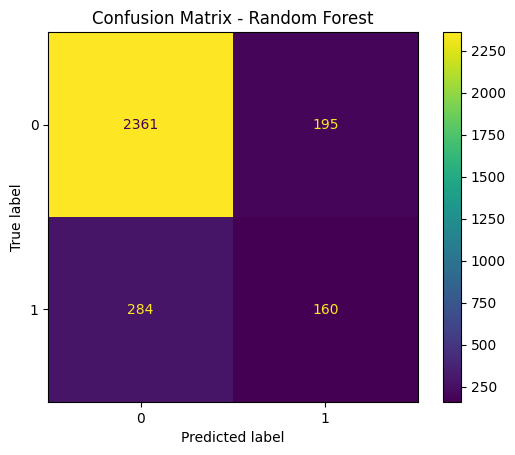


Model: Voting Classifier
Accuracy  : 0.8510
Precision : 0.4516
Recall    : 0.0315
F1-Score  : 0.0589

Confusion Matrix:


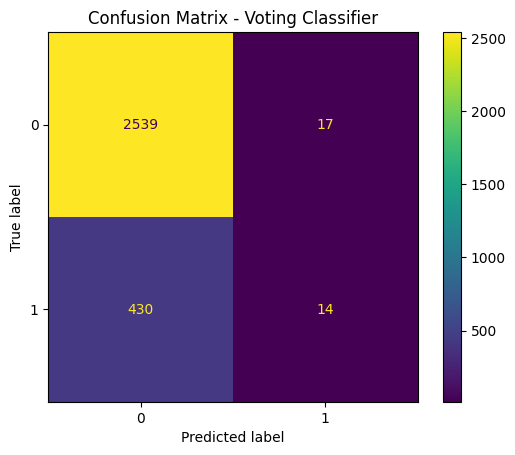

In [ ]:
for nama, model in [('Logistic Regression', lr), ('Random Forest', rf), ('Voting Classifier', voting)]:
    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Model: {nama}")
    print(f"{'='*50}")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"\nConfusion Matrix:")
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
    plt.title(f'Confusion Matrix - {nama}')
    plt.show()

### Preprocessing Data

In [ ]:
# Daftar nilai yang dianggap sebagai missing value
nilai_kosong = ['nan', 'NaN', 'NAN', 'null', 'Null', 'NULL', 'NUUL',
                 '?', '??', '???', '!', '!!', '!!!', '-', '--', '',
                 'none', 'None', 'NONE', 'n/a', 'N/A', 'na', 'NA']

df_clean = df.copy()

# Ganti semua nilai tidak standar menjadi NaN
df_clean.replace(nilai_kosong, np.nan, inplace=True)

print("Jumlah missing value setelah standarisasi:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Hapus duplikasi
df_clean.drop_duplicates(inplace=True)
print("\nJumlah data setelah hapus duplikasi:", df_clean.shape[0])

# Isi missing value numerik dengan median, kategorikal dengan modus
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Missing value tersisa:", df_clean.isnull().sum().sum())

# Hapus outlier menggunakan metode IQR
num_cols_clean = df_clean.select_dtypes(include='number').columns.tolist()
num_cols_clean = [col for col in num_cols_clean if col not in ['churn', 'customer_id']]

for col in num_cols_clean:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5 * IQR) & (df_clean[col] <= Q3 + 1.5 * IQR)]

print("Jumlah data setelah hapus outlier:", df_clean.shape[0])

Jumlah missing value setelah standarisasi:
gender                 738
age                   1200
total_spent           1050
coupon_code           6133
satisfaction_score     702
dtype: int64

Jumlah data setelah hapus duplikasi: 15000
Missing value tersisa: 0
Jumlah data setelah hapus outlier: 11506


In [ ]:
# Drop kolom yang tidak relevan
df_clean.drop(columns=['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code'], inplace=True)

# Encoding kolom kategorikal menggunakan LabelEncoder
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Kolom setelah encoding:", df_clean.columns.tolist())
print("Tipe data setelah encoding:")
print(df_clean.dtypes)

Kolom setelah encoding: ['gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']
Tipe data setelah encoding:
gender                          int64
age                           float64
country                         int64
city                            int64
acquisition_channel             int64
device_type                     int64
subscription_type               int64
is_premium_user                 int64
total_visits                    int64
avg_session_time              float64
pages_per_session             float64
email_open_rate               float64
email_click_rate              

Distribusi churn sebelum SMOTE (data latih):
churn
0    7947
1    1257
Name: count, dtype: int64

Distribusi churn setelah SMOTE (data latih):
churn
0    7947
1    7947
Name: count, dtype: int64

Model: Logistic Regression
Accuracy  : 0.7480
Precision : 0.3197
Recall    : 0.7460
F1-Score  : 0.4476

Confusion Matrix:


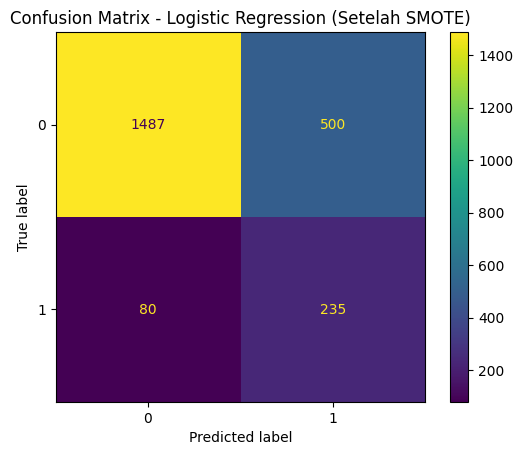


Model: Random Forest
Accuracy  : 0.8732
Precision : 0.5240
Recall    : 0.7968
F1-Score  : 0.6322

Confusion Matrix:


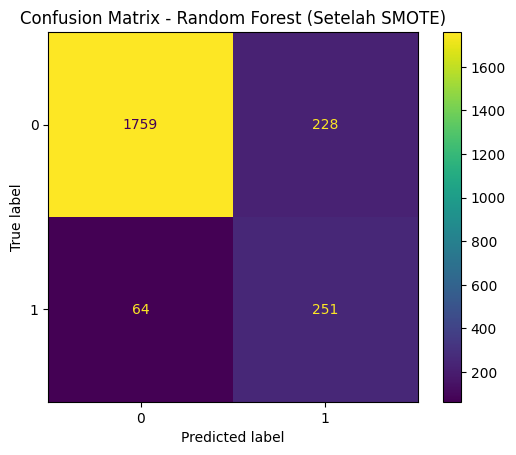


Model: Voting Classifier
Accuracy  : 0.8041
Precision : 0.3910
Recall    : 0.7746
F1-Score  : 0.5197

Confusion Matrix:


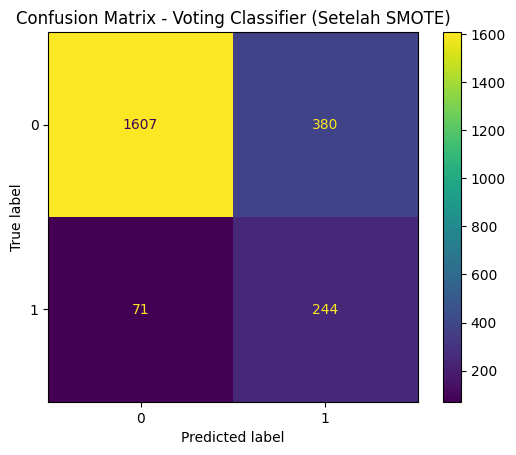

Distribusi churn sebelum SMOTE (data latih):
churn
0    7947
1    1257
Name: count, dtype: int64

Distribusi churn setelah SMOTE (data latih):
churn
0    7947
1    7947
Name: count, dtype: int64

Model: Logistic Regression
Accuracy  : 0.7480
Precision : 0.3197
Recall    : 0.7460
F1-Score  : 0.4476

Confusion Matrix:


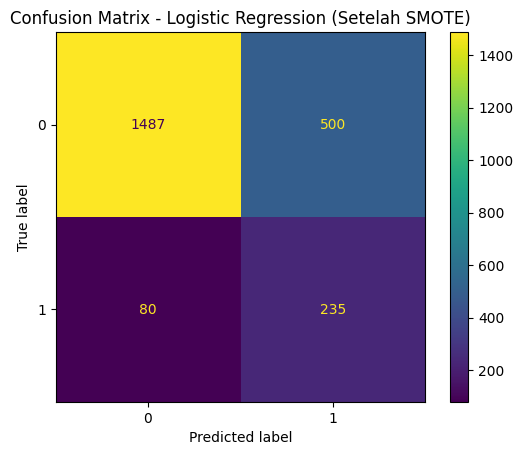


Model: Random Forest
Accuracy  : 0.8732
Precision : 0.5240
Recall    : 0.7968
F1-Score  : 0.6322

Confusion Matrix:


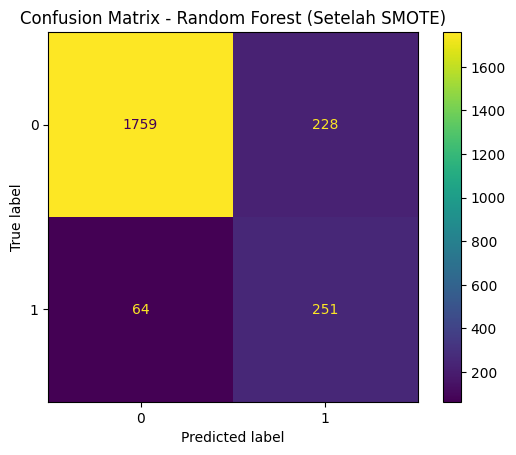


Model: Voting Classifier
Accuracy  : 0.8041
Precision : 0.3910
Recall    : 0.7746
F1-Score  : 0.5197

Confusion Matrix:


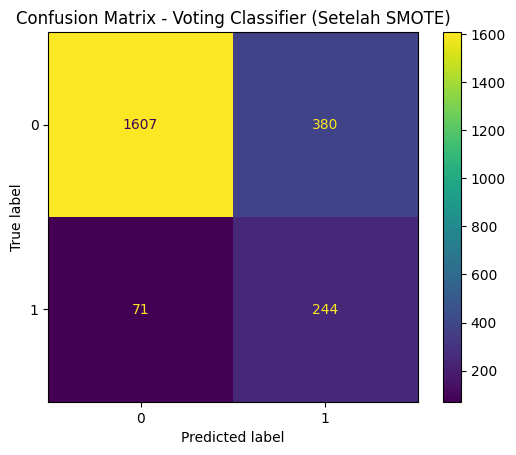

In [ ]:
# Pisahkan fitur dan target
X2 = df_clean.drop(columns=['churn'])
y2 = df_clean['churn']

# Split data dengan stratify agar proporsi churn terjaga
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Distribusi churn sebelum SMOTE (data latih):")
print(y2_train.value_counts())

# Scaling setelah split
scaler = StandardScaler()
X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

# Balancing data dengan SMOTE
smote = SMOTE(random_state=42)
X2_train, y2_train = smote.fit_resample(X2_train, y2_train)

print("\nDistribusi churn setelah SMOTE (data latih):")
print(pd.Series(y2_train).value_counts())

# Inisialisasi ulang model
lr2 = LogisticRegression(random_state=42)
rf2 = RandomForestClassifier(random_state=42)
voting2 = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=42)),
    ('svm', SVC(random_state=42)),
    ('knn', KNeighborsClassifier())
], voting='hard')

# Training ketiga model dengan data hasil SMOTE
lr2.fit(X2_train, y2_train)
rf2.fit(X2_train, y2_train)
voting2.fit(X2_train, y2_train)

# Evaluasi ketiga model
for nama, model in [('Logistic Regression', lr2), ('Random Forest', rf2), ('Voting Classifier', voting2)]:
    y_pred = model.predict(X2_test)

for nama, model in [('Logistic Regression', lr2), ('Random Forest', rf2), ('Voting Classifier', voting2)]:
    y_pred = model.predict(X2_test)
    print(f"\n{'='*50}")
    print(f"Model: {nama}")
    print(f"{'='*50}")
    print(f"Accuracy  : {accuracy_score(y2_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y2_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y2_test, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y2_test, y_pred):.4f}")
    print(f"\nConfusion Matrix:")
    ConfusionMatrixDisplay(confusion_matrix(y2_test, y_pred)).plot()
    plt.title(f'Confusion Matrix - {nama} (Setelah SMOTE)')
    plt.show()

### Seleksi Fitur & Penyetelan Hyperparameter (Tuning)

Feature Importance:
total_spent                   0.287800
satisfaction_score            0.236744
support_tickets               0.117539
country                       0.034314
payment_method                0.027945
device_type                   0.027454
city                          0.025346
last_3_month_purchase_freq    0.019057
marketing_spend_per_user      0.018513
nps_score                     0.018020
delivery_delay_days           0.016997
lifetime_value                0.016961
avg_session_time              0.016760
avg_order_value               0.016696
email_open_rate               0.016447
pages_per_session             0.015531
acquisition_channel           0.015253
email_click_rate              0.014935
age                           0.014929
total_visits                  0.014782
gender                        0.013760
subscription_type             0.005462
discount_used                 0.004382
is_premium_user               0.004375
refund_requested              0.000000
dtype

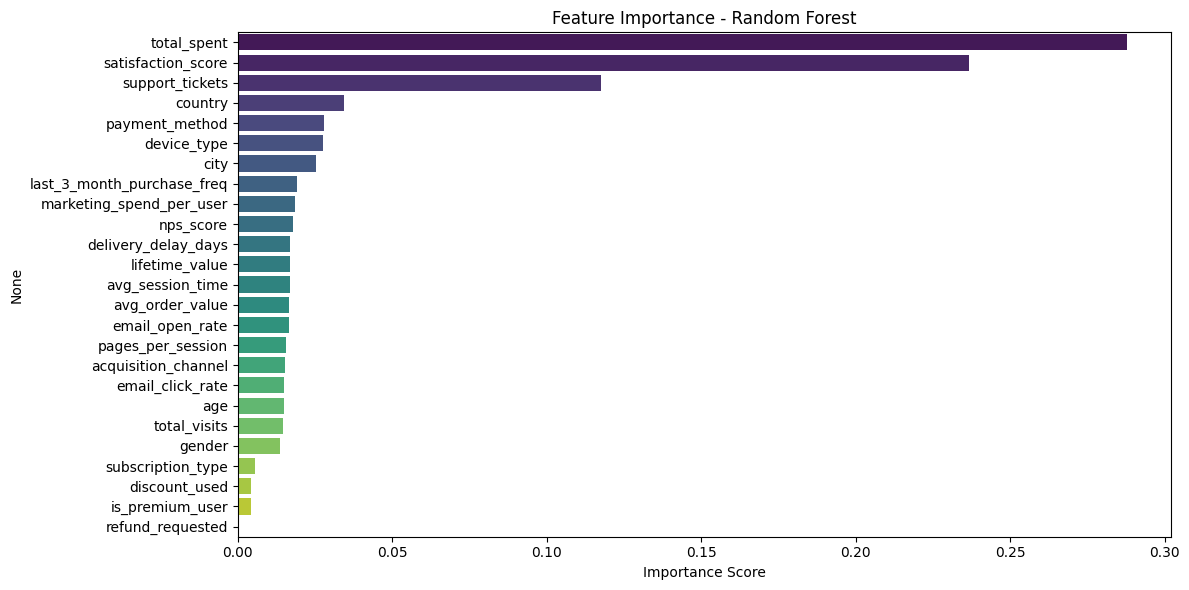


Top 15 fitur terpenting: ['total_spent', 'satisfaction_score', 'support_tickets', 'country', 'payment_method', 'device_type', 'city', 'last_3_month_purchase_freq', 'marketing_spend_per_user', 'nps_score', 'delivery_delay_days', 'lifetime_value', 'avg_session_time', 'avg_order_value', 'email_open_rate']


In [ ]:
# Analisis feature importance menggunakan Random Forest
feature_importance = pd.Series(rf2.feature_importances_, index=df_clean.drop(columns=['churn']).columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Pilih top 15 fitur terpenting
top_features = feature_importance.head(15).index.tolist()
print("\nTop 15 fitur terpenting:", top_features)

In [ ]:
# Parameter grid untuk masing-masing model
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 500]
}

param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_voting = {
    'lr__C': [0.1, 1, 10],
    'lr__max_iter': [100, 200],
    'knn__n_neighbors': [3, 5, 7],
    'svm__C': [0.1, 1, 10]
}

# Gunakan top fitur untuk tuning (data hasil SMOTE)
X2_train_top = pd.DataFrame(X2_train, columns=df_clean.drop(columns=['churn']).columns)[top_features].values
X2_test_top  = pd.DataFrame(X2_test,  columns=df_clean.drop(columns=['churn']).columns)[top_features].values

# Tuning masing-masing model
tuning_lr = RandomizedSearchCV(LogisticRegression(random_state=42), param_lr,
                                n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1)
tuning_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_rf,
                                n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1)
tuning_voting = RandomizedSearchCV(VotingClassifier(estimators=[
                    ('lr', LogisticRegression(random_state=42)),
                    ('svm', SVC(random_state=42)),
                    ('knn', KNeighborsClassifier())
                ], voting='hard'), param_voting,
                n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1)

tuning_lr.fit(X2_train_top, y2_train)
tuning_rf.fit(X2_train_top, y2_train)
tuning_voting.fit(X2_train_top, y2_train)

print("Best Params Logistic Regression:", tuning_lr.best_params_)
print("Best Params Random Forest      :", tuning_rf.best_params_)
print("Best Params Voting Classifier  :", tuning_voting.best_params_)

Best Params Logistic Regression: {'solver': 'liblinear', 'max_iter': 100, 'C': 0.01}
Best Params Random Forest      : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5}
Best Params Voting Classifier  : {'svm__C': 10, 'lr__max_iter': 200, 'lr__C': 0.1, 'knn__n_neighbors': 3}
Best Params Logistic Regression: {'solver': 'liblinear', 'max_iter': 100, 'C': 0.01}
Best Params Random Forest      : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5}
Best Params Voting Classifier  : {'svm__C': 10, 'lr__max_iter': 200, 'lr__C': 0.1, 'knn__n_neighbors': 3}



Model: Logistic Regression
Best Params: {'solver': 'liblinear', 'max_iter': 100, 'C': 0.01}
Accuracy  : 0.7476
Precision : 0.3241
Recall    : 0.7778
F1-Score  : 0.4575

Confusion Matrix:


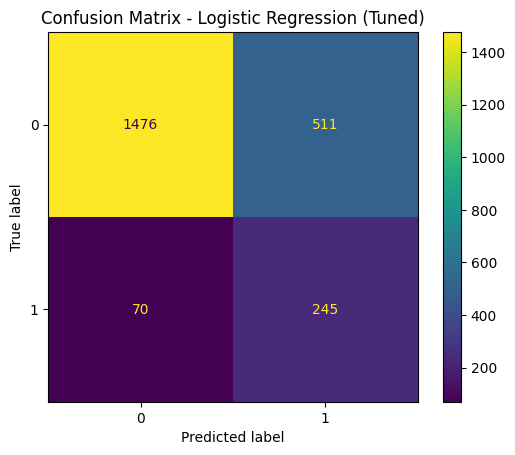


Model: Random Forest
Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5}
Accuracy  : 0.8619
Precision : 0.4975
Recall    : 0.9651
F1-Score  : 0.6566

Confusion Matrix:


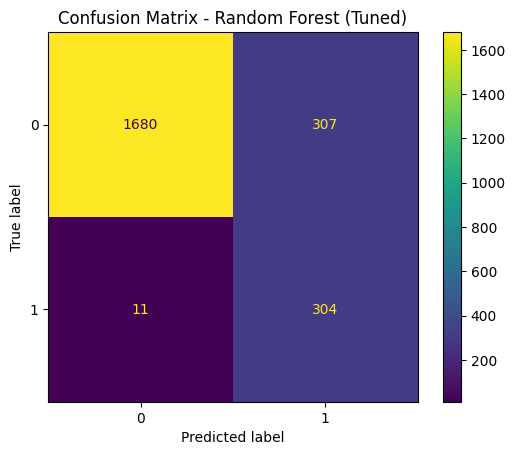


Model: Voting Classifier
Best Params: {'svm__C': 10, 'lr__max_iter': 200, 'lr__C': 0.1, 'knn__n_neighbors': 3}
Accuracy  : 0.8241
Precision : 0.4154
Recall    : 0.7016
F1-Score  : 0.5218

Confusion Matrix:


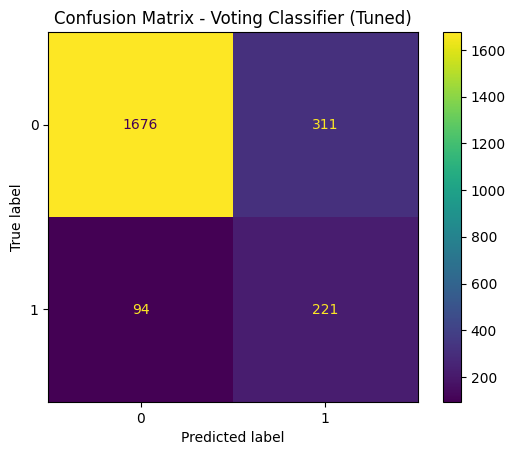


Model: Logistic Regression
Best Params: {'solver': 'liblinear', 'max_iter': 100, 'C': 0.01}
Accuracy  : 0.7476
Precision : 0.3241
Recall    : 0.7778
F1-Score  : 0.4575

Confusion Matrix:


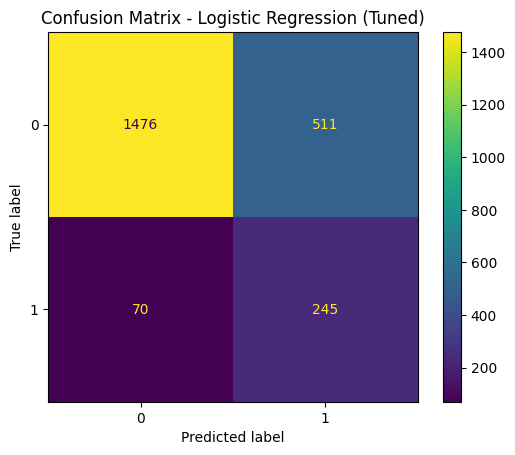


Model: Random Forest
Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5}
Accuracy  : 0.8619
Precision : 0.4975
Recall    : 0.9651
F1-Score  : 0.6566

Confusion Matrix:


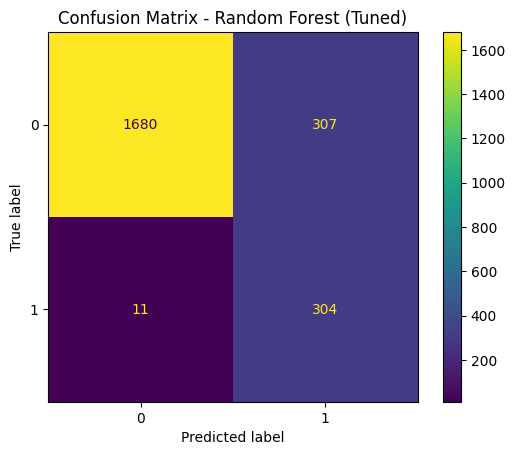


Model: Voting Classifier
Best Params: {'svm__C': 10, 'lr__max_iter': 200, 'lr__C': 0.1, 'knn__n_neighbors': 3}
Accuracy  : 0.8241
Precision : 0.4154
Recall    : 0.7016
F1-Score  : 0.5218

Confusion Matrix:


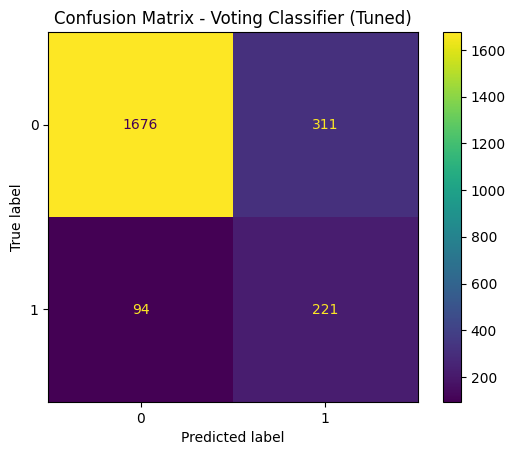

In [ ]:
for nama, tuning in [('Logistic Regression', tuning_lr), ('Random Forest', tuning_rf), ('Voting Classifier', tuning_voting)]:
    best_model = tuning.best_estimator_
    y_pred = best_model.predict(X2_test_top)
    print(f"\n{'='*50}")
    print(f"Model: {nama}")
    print(f"Best Params: {tuning.best_params_}")
    print(f"{'='*50}")
    print(f"Accuracy  : {accuracy_score(y2_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y2_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y2_test, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y2_test, y_pred):.4f}")
    print(f"\nConfusion Matrix:")
    ConfusionMatrixDisplay(confusion_matrix(y2_test, y_pred)).plot()
    plt.title(f'Confusion Matrix - {nama} (Tuned)')
    plt.show()

### Perbandingan & Penyimpanan Model Akhir

In [ ]:
# Bandingkan F1-Score ketiga model setelah tuning
results = {}
for nama, tuning in [('Logistic Regression', tuning_lr), ('Random Forest', tuning_rf), ('Voting Classifier', tuning_voting)]:
    best_model = tuning.best_estimator_
    y_pred = best_model.predict(X2_test_top)
    results[nama] = {
        'model': best_model,
        'f1': f1_score(y2_test, y_pred),
        'accuracy': accuracy_score(y2_test, y_pred)
    }

# Tampilkan perbandingan
results_df = pd.DataFrame({k: {'F1-Score': v['f1'], 'Accuracy': v['accuracy']} for k, v in results.items()}).T
print("Perbandingan Model Setelah Tuning:")
print(results_df.sort_values('F1-Score', ascending=False))

# Pilih model terbaik berdasarkan F1-Score
best_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_name]['model']
print(f"\nModel terbaik: {best_name}")

Perbandingan Model Setelah Tuning:
                     F1-Score  Accuracy
Random Forest        0.656587  0.861859
Voting Classifier    0.521842  0.824066
Logistic Regression  0.457516  0.747611

Model terbaik: Random Forest
Perbandingan Model Setelah Tuning:
                     F1-Score  Accuracy
Random Forest        0.656587  0.861859
Voting Classifier    0.521842  0.824066
Logistic Regression  0.457516  0.747611

Model terbaik: Random Forest


In [ ]:
# Buat scaler khusus untuk top_features saja (dipakai di Streamlit nanti)
scaler_top = StandardScaler()
X2_train_df = pd.DataFrame(X2_train, columns=df_clean.drop(columns=['churn']).columns)
scaler_top.fit(X2_train_df[top_features])

# Simpan model terbaik, scaler, dan daftar fitur ke /content
joblib.dump(best_model, '/content/best_model.joblib')
joblib.dump(scaler_top, '/content/scaler.joblib')
joblib.dump(top_features, '/content/top_features.joblib')

print("Model, scaler, dan fitur berhasil disimpan!")
print(os.listdir('/content')) if 'os' in dir() else print("Cek panel Files di sidebar kiri")

Model, scaler, dan fitur berhasil disimpan!
Cek panel Files di sidebar kiri
Model, scaler, dan fitur berhasil disimpan!
Cek panel Files di sidebar kiri
